In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
os.listdir('/content')

['.config', 'Dataset.xlsx', 'sample_data']

In [ ]:
df = pd.read_excel('/content/Dataset.xlsx')
print(df)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

In [ ]:
# Quick look
print(df.head())

print(df.info())
df.shape
print(df['Loan_Status'].value_counts())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


<Axes: >

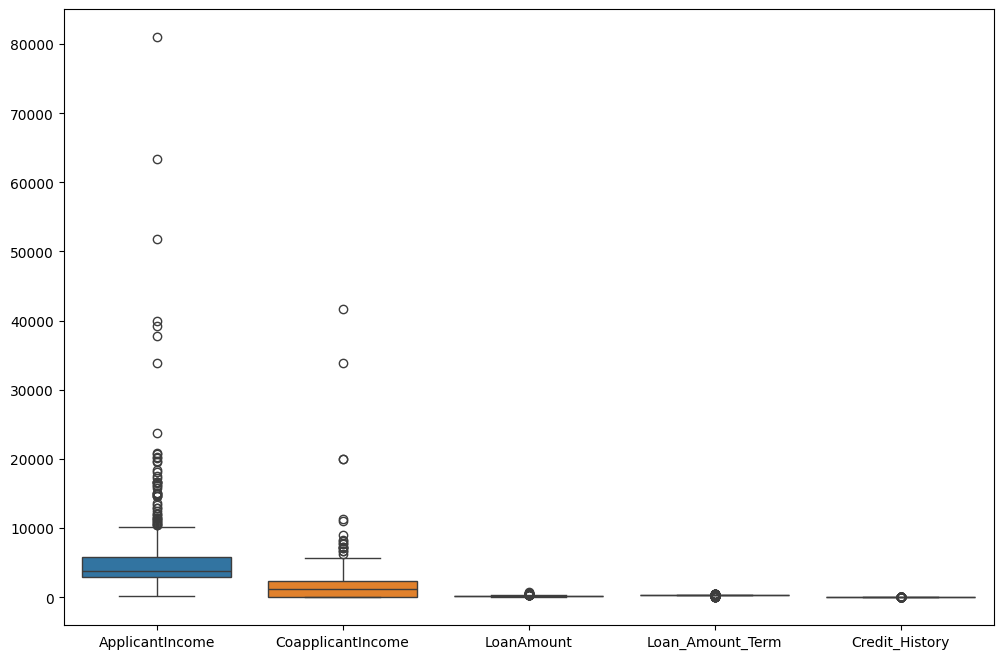

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(data = df)

In [ ]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Num of people  took loan by gender
Gender
Male      502
Female    112
Name: count, dtype: int64


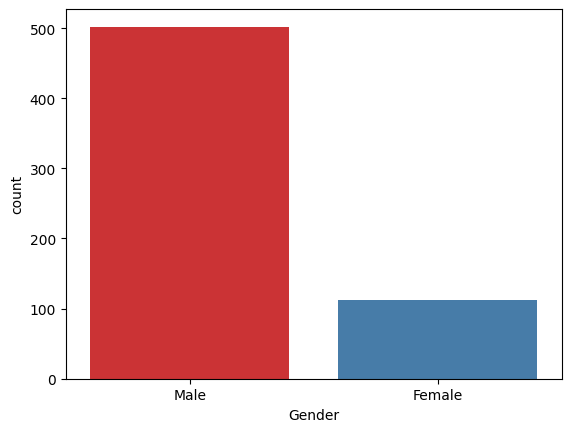

In [ ]:
print('Num of people  took loan by gender')
print(df['Gender'].value_counts())
sns.countplot(x='Gender',data = df, palette='Set1')
plt.show()

Num of people who took loan by Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


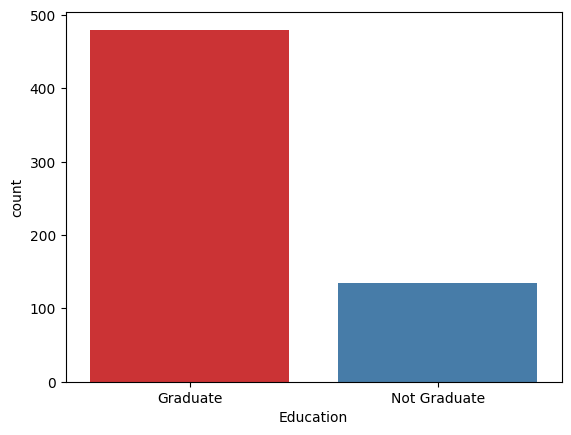

In [ ]:
print('Num of people who took loan by Education')
print(df['Education'].value_counts())
sns.countplot(x='Education',data = df, palette='Set1')
plt.show()

<Axes: >

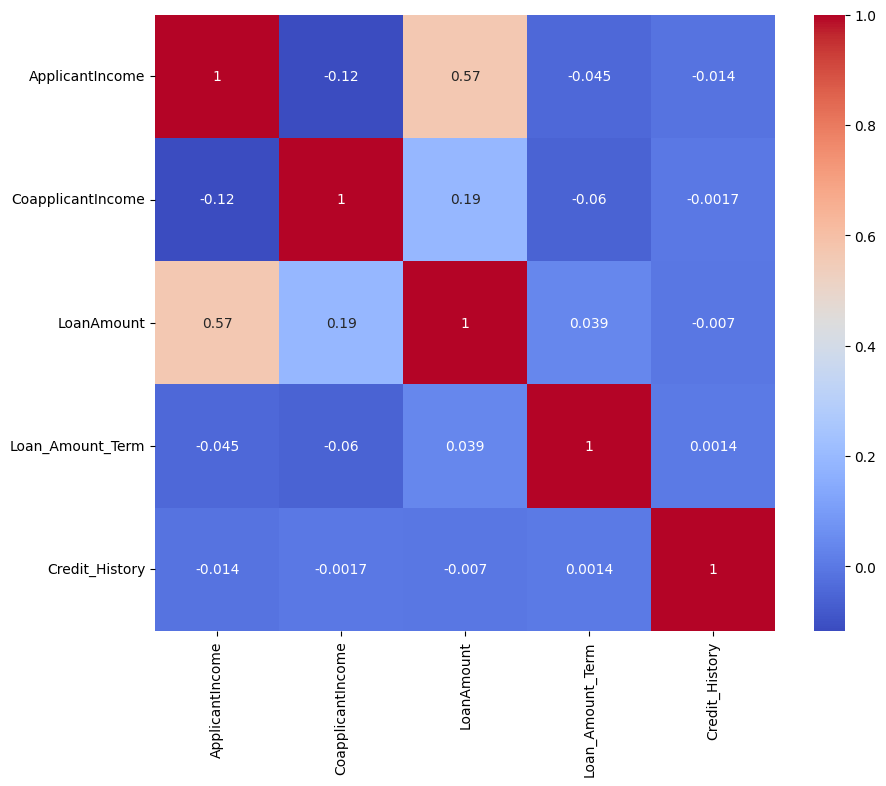

In [ ]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot = True, cmap = 'coolwarm')

In [ ]:
corr = df.select_dtypes(include='number').corr()
corr

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.045242,-0.014477
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059675,-0.001665
LoanAmount,0.565181,0.189218,1.000000,0.039235,-0.007031
Loan_Amount_Term,-0.045242,-0.059675,0.039235,1.000000,0.001395
Credit_History,-0.014477,-0.001665,-0.007031,0.001395,1.000000


In [ ]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


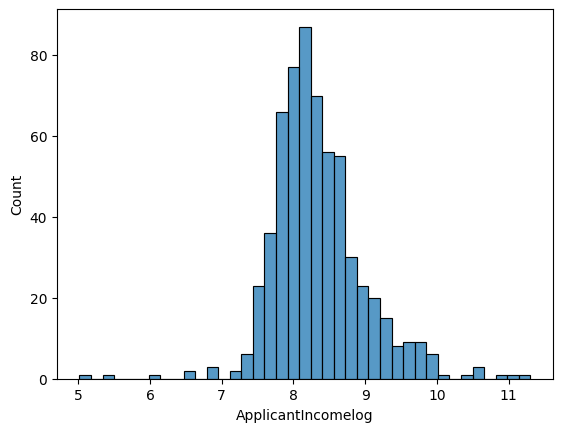

In [ ]:
df['ApplicantIncomelog'] = np.log(df['ApplicantIncome'] + 1)
sns.histplot(df['ApplicantIncomelog'])
plt.show()

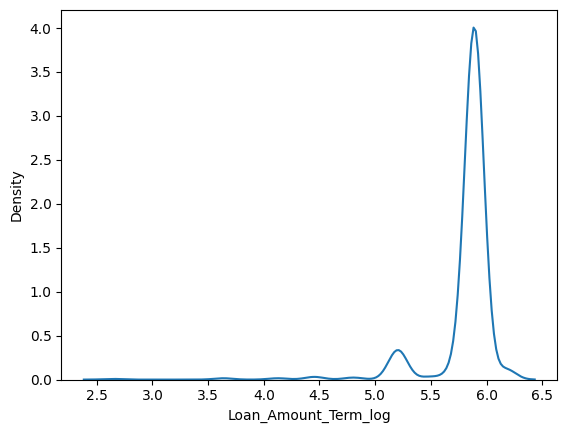

In [ ]:

df['Loan_Amount_Term_log'] = np.log(df['Loan_Amount_Term'] + 2)
sns.kdeplot(df['Loan_Amount_Term_log'])
plt.show()

In [ ]:
cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Total_Income','Loan_ID']
df = df.drop(columns = cols, axis = 1)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,Loan_Amount_Term_log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674197,5.891644
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430327,5.891644
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006701,5.891644
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.857094,5.891644
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699681,5.891644


In [ ]:
pip install -U imbalanced-learn


In [ ]:
for col in cols:
  df[col]=df[col].astype('str')

In [ ]:
from sklearn.preprocessing import LabelEncoder
cols = ['Gender','Married','Education','Dependents','Self_Employed','Property_Area','Loan_Status']
le =  LabelEncoder()
for col in cols:
  df[col] =  le.fit_transform(df[col])


In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomelog,Loan_Amount_Term_log
0,1,0,0,0,0,1.0,2,1,8.674197,5.891644
1,1,1,1,0,0,1.0,0,0,8.430327,5.891644
2,1,1,0,0,1,1.0,2,1,8.006701,5.891644
3,1,1,0,1,0,1.0,2,1,7.857094,5.891644
4,1,0,0,0,0,1.0,2,1,8.699681,5.891644


In [ ]:
X = df.drop(columns = ['Loan_Status'],axis = 1)
y = df['Loan_Status']

In [ ]:
X

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,ApplicantIncomelog,Loan_Amount_Term_log
0,1,0,0,0,0,1.0,2,8.674197,5.891644
1,1,1,1,0,0,1.0,0,8.430327,5.891644
2,1,1,0,0,1,1.0,2,8.006701,5.891644
3,1,1,0,1,0,1.0,2,7.857094,5.891644
4,1,0,0,0,0,1.0,2,8.699681,5.891644
...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,1.0,0,7.972811,5.891644
610,1,1,3,0,0,1.0,0,8.320448,5.204007
611,1,1,1,0,0,1.0,2,8.996280,5.891644
612,1,1,2,0,0,1.0,2,8.933796,5.891644


In [ ]:
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model1 = LogisticRegression()
model1.fit(X_train, y_train)

y_pred_model1 = model1.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_model1)
print("Accuracy:", accuracy)

Accuracy: 0.7727272727272727


In [ ]:
score = cross_val_score(model1,X,y,cv=5)
score

array([0.81300813, 0.7804878 , 0.7804878 , 0.85365854, 0.81967213])

In [ ]:
print(np.mean(score))

0.809462881514061


In [ ]:
model2 = DecisionTreeClassifier()
model2.fit(X_train,y_train)
y_pred_model2 = model2.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model2)
print("Accuracy score of Decision Tree: ", accuracy)

score = cross_val_score(model2,X,y,cv=5)
print("Cross Validation score : ",np.mean(score))

Accuracy score of Decision Tree:  0.7402597402597403
Cross Validation score :  0.7214447554311608


In [ ]:
model3 = RandomForestClassifier()
model3.fit(X_train,y_train)
y_pred_model3 = model3.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model3)
print("Accuracy score of Random Forest: ", accuracy)

Accuracy score of Random Forest:  0.7272727272727273


In [ ]:
model4 = KNeighborsClassifier(n_neighbors=4)
model4.fit(X_train,y_train)
y_pred_model4 = model4.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_model4)
print("Accuracy score of KNeighbors: ", accuracy)

Accuracy score of KNeighbors:  0.6948051948051948


In [ ]:
from sklearn.metrics import classification_report
def generate_classification_report(model_name,y_test,y_pred):
  report = classification_report(y_test,y_pred)
  print(f"Classification Report For {model_name}:\n{report}\n")

generate_classification_report(model1,y_test,y_pred_model1)
generate_classification_report(model2,y_test,y_pred_model2)
generate_classification_report(model3,y_test,y_pred_model3)
generate_classification_report(model4,y_test,y_pred_model4)

Classification Report For LogisticRegression():
              precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154


Classification Report For DecisionTreeClassifier():
              precision    recall  f1-score   support

           0       0.65      0.56      0.60        54
           1       0.78      0.84      0.81       100

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Classification Report For RandomForestClassifier():
              precision    recall  f1-score   support

           0       0.67      0.44      0.53        54
           1       0.75      0.88      0.81       100

    accuracy                

In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
1,422
0,192


In [ ]:
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversample.fit_resample(X,y)

df_resampled = pd.concat([pd.DataFrame(X_resampled,columns=X.columns),pd.Series(y_resampled,name="Loan_status")],axis=1)

In [ ]:
X_resampled

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,ApplicantIncomelog,Loan_Amount_Term_log
0,1,0,0,0,0,1.000000,2,8.674197,5.891644
1,1,1,1,0,0,1.000000,0,8.430327,5.891644
2,1,1,0,0,1,1.000000,2,8.006701,5.891644
3,1,1,0,1,0,1.000000,2,7.857094,5.891644
4,1,0,0,0,0,1.000000,2,8.699681,5.891644
...,...,...,...,...,...,...,...,...,...
839,1,1,3,1,0,1.000000,2,8.292298,5.204007
840,1,1,1,0,0,0.842199,0,7.539559,5.891644
841,1,1,1,0,0,0.000000,0,7.933080,5.891644
842,1,1,2,1,0,0.000000,2,7.969012,5.204007


In [ ]:
y_resampled

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
839,0
840,0
841,0
842,0


In [ ]:
y_resampled.value_counts()

,count
Loan_Status,
1,422
0,422


In [ ]:
X_resampled_train, X_resampled_test, y_resampled_train, y_resampled_test = train_test_split(X_resampled,y_resampled,test_size = 0.25,random_state=42)

In [ ]:
model1 = LogisticRegression()
model1.fit(X_resampled_train,y_resampled_train)
y_pred_model1 = model1.predict(X_resampled_test)
accuracy = accuracy_score(y_resampled_test,y_pred_model1)
accuracy

0.6872037914691943

In [ ]:
pip install xgboost


In [ ]:
import xgboost as xgb
le = LabelEncoder()

categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Accuracy: 0.7804878048780488


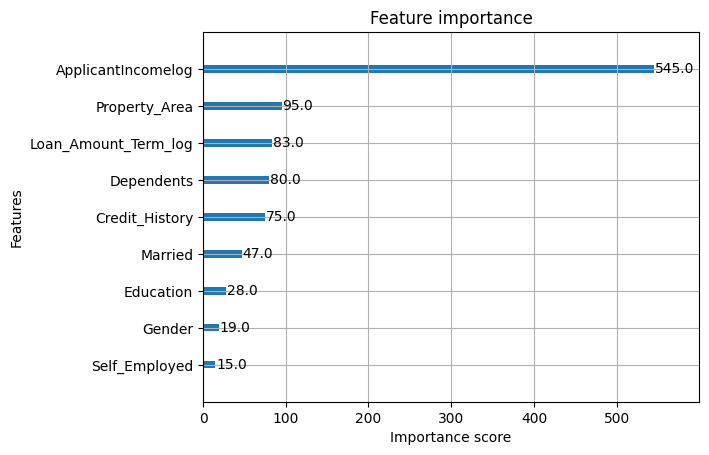

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()